# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 5. Поиск типичных подпоследовательностей временного ряда.**

In [ ]:
%load_ext autoreload
%autoreload 2

In [10]:
# Клонируем свой форк репозитория с GitHub
!git clone https://github.com/QFXzZ/2025-Selyutin-TimeSeriesCourse.git

fatal: destination path '2025-Selyutin-TimeSeriesCourse' already exists and is not an empty directory.


In [11]:
%cd 2025-Selyutin-TimeSeriesCourse/practice/"05 Snippets"

/content/2025-Selyutin-TimeSeriesCourse/practice/05 Snippets


In [12]:
!ls

'05 Snippets.ipynb'   2025-Selyutin-TimeSeriesCourse   datasets   modules


Импорт библиотек и модулей

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from modules.snippets import *
from scipy import signal
from stumpy import snippets
import pandas as pd

### **Задача 1. Поиск сниппетов одномерного временного ряда**

В первой задаче необходимо выполнить поиск сниппетов одномерного временного ряда. Расмотрите приведенный ниже пример использования алгоритма SnipperFinder и визуализации полученных результатов для искуственного врменного ряда.

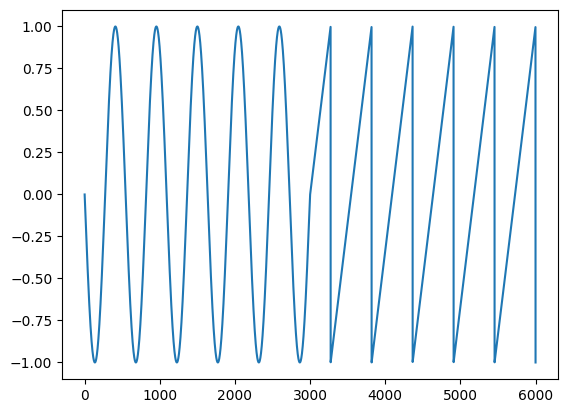

In [14]:
#Создание искусственного временного ряда
t = np.linspace(np.pi, 6 * 2 * np.pi, 3000)
ts = np.concatenate([np.sin(t), signal.sawtooth(t)])
plt.plot(ts)

In [15]:
#Поиск сниппетов
snp = snippets(ts, 600, 2, percentage=0.5)

600


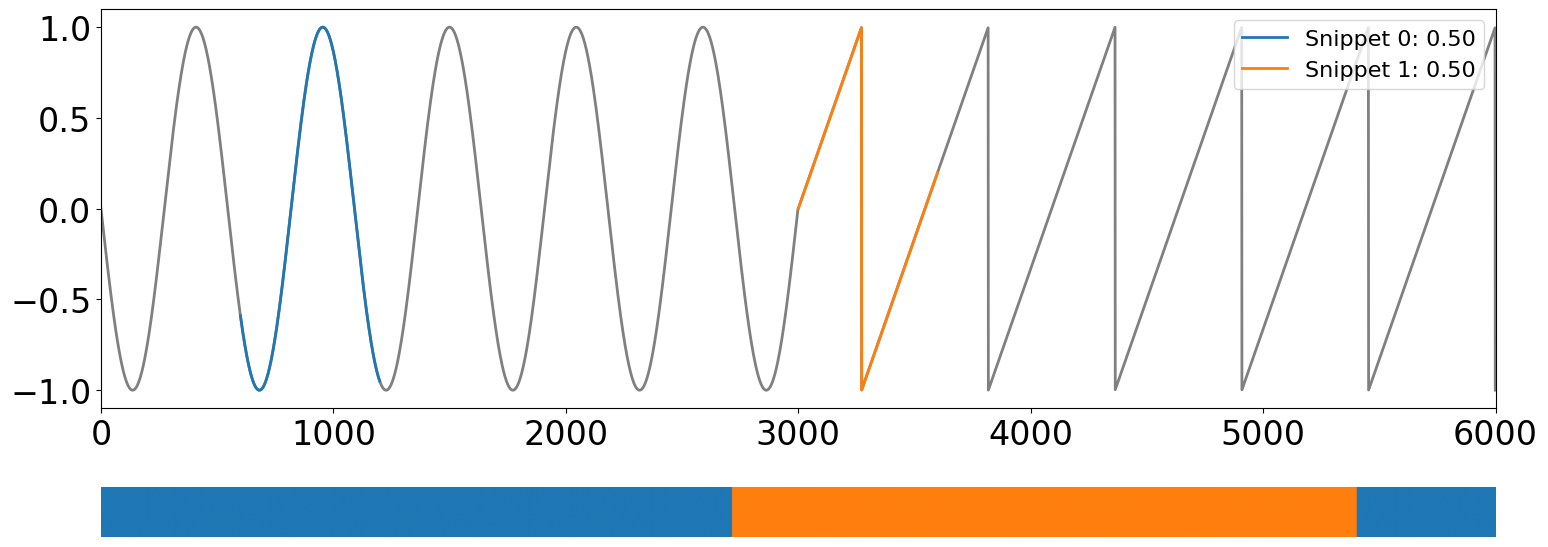

<Axes: >

In [16]:
#Визуализация результатов
plot_snippets(ts, snp)

Далее вам предстоит самостоятельно выполнить поиск top-$k$ типичных подпоследовательностей временного ряда (сниппетов) с помощью алгоритма SnippetFinder на наборе данных PAMAP. Описание набора данных находится в [README-файле](datasets/PAMAP/readme.md).

Выполните считывание временного ряда **показаний гироскопа на оси «Y» (угол тангажа) на временном интервале от 1790 сек. до 1930 сек.** (используя колонку с временными метками) из файла *PAMAP.txt*, который располагается в директории *./datasets/PAMAP*. Затем выполните поиск сниппетов с помощью функции `snippets()` из библиотеки stumpy. Затем визуализируйте полученные результаты, используя функцию `plot_snippets()` из модуля snippets.py.

In [22]:
from google.colab import files

uploaded = files.upload()

filename = list(uploaded.keys())[0]

Saving subject101.dat to subject101.dat


In [23]:
import pandas as pd

# Определяем названия колонок PAMAP2 (54 колонки)
cols = ["timestamp", "activityID", "heart_rate"] + \
       ["temp_hand"] + ["acc16_hand_x","acc16_hand_y","acc16_hand_z"] + \
       ["acc6_hand_x","acc6_hand_y","acc6_hand_z"] + \
       ["gyro_hand_x","gyro_hand_y","gyro_hand_z"] + \
       ["mag_hand_x","mag_hand_y","mag_hand_z"] + \
       ["orient1_hand","orient2_hand","orient3_hand","orient4_hand"] + \
       ["temp_chest"] + ["acc16_chest_x","acc16_chest_y","acc16_chest_z"] + \
       ["acc6_chest_x","acc6_chest_y","acc6_chest_z"] + \
       ["gyro_chest_x","gyro_chest_y","gyro_chest_z"] + \
       ["mag_chest_x","mag_chest_y","mag_chest_z"] + \
       ["orient1_chest","orient2_chest","orient3_chest","orient4_chest"] + \
       ["temp_ankle"] + ["acc16_ankle_x","acc16_ankle_y","acc16_ankle_z"] + \
       ["acc6_ankle_x","acc6_ankle_y","acc6_ankle_z"] + \
       ["gyro_ankle_x","gyro_ankle_y","gyro_ankle_z"] + \
       ["mag_ankle_x","mag_ankle_y","mag_ankle_z"] + \
       ["orient1_ankle","orient2_ankle","orient3_ankle","orient4_ankle"]

In [24]:
# Чтение .dat файла
df = pd.read_csv(filename, sep=r"\s+", header=None, names=cols, na_values=["NaN"])

In [25]:
# Параметры фильтрации
start_time = 1790
end_time = 1930

# Фильтруем DataFrame по timestamp
df_interval = df[(df['timestamp'] >= start_time) & (df['timestamp'] <= end_time)]

# Берём временной ряд gyro_y Hand IMU
ts = df_interval['gyro_hand_y'].to_numpy()
timestamps = df_interval['timestamp'].to_numpy()

In [26]:
# Параметры поиска сниппетов
m = 50          # длина подпоследовательности
k = 3           # сколько топ-k сниппетов ищем
percentage = 0.5  # процент схожести

In [27]:
snp = snippets(ts, m=m, k=k, percentage=percentage)

Выполните визулизацию временного ряда и найденных сниппетов с помощью функции `plot_snippets()` из модуля snippets.py.

50


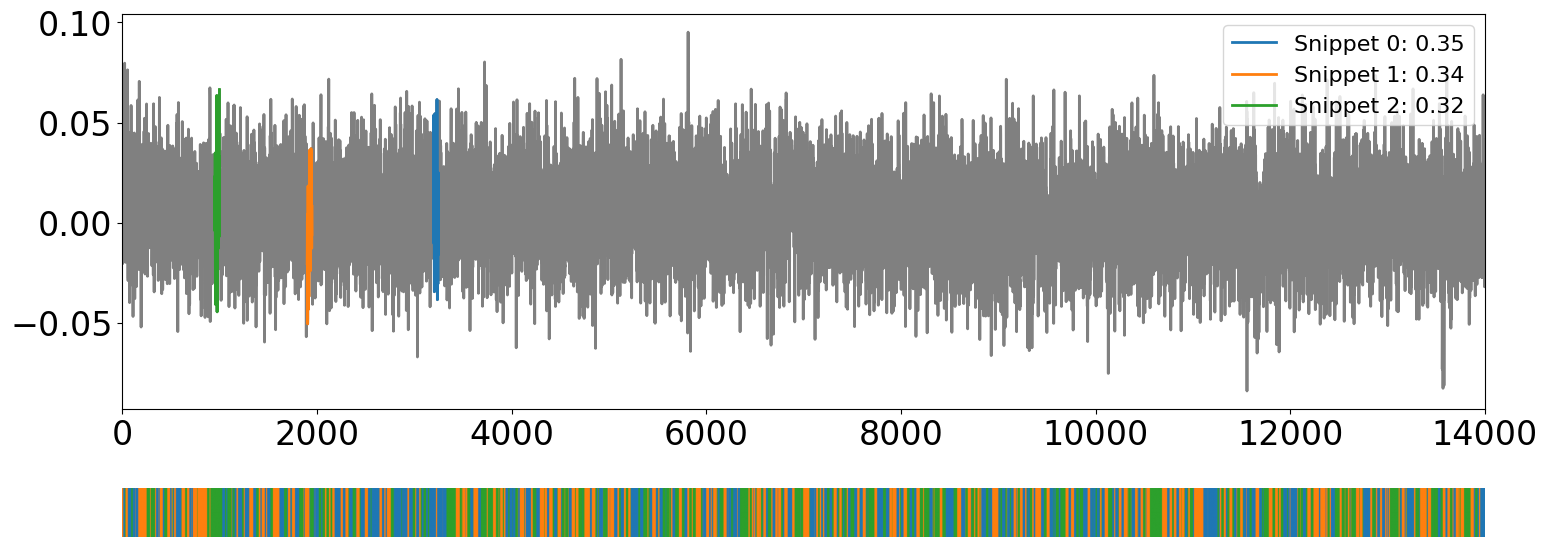

<Axes: >

In [28]:
# INSERT YOUR CODE
plot_snippets(ts, snp)

Оцените точность разметки, полученной при помощи сниппетов, используя исходные данные об активностях в ряде.

In [31]:
# INSERT YOUR CODE

snippet_indices = snp[1]   # стартовые индексы сниппетов
snippet_labels = snp[3]    # расстояние/оценка паттерна
snippet_regimes = snp[5]   # (label, start, end)

m = snp[0].shape[0]  # длина сниппета

accuracies = []

for i, start_idx in enumerate(snippet_indices):
    end_idx = start_idx + m
    # Извлекаем activityID для этого сниппета
    activities = df_interval['activityID'].iloc[start_idx:end_idx].to_numpy()

    # Определяем основную активность (мода)
    if len(activities) == 0:
        continue
    main_activity = np.bincount(activities.astype(int)).argmax()

    # Считаем, сколько точек совпадает с основной активностью
    correct = np.sum(activities == main_activity)
    acc = correct / len(activities)
    accuracies.append(acc)

    print(f"Snippet {i}: основная активность = {main_activity}, точность = {acc:.2f}")

# Средняя точность по всем сниппетам
print(f"\nСредняя точность сниппетов: {np.mean(accuracies):.2f}")


Snippet 0: основная активность = 9, точность = 1.00
Snippet 1: основная активность = 9, точность = 1.00
Snippet 2: основная активность = 9, точность = 1.00

Средняя точность сниппетов: 1.00


❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Сниппеты - это типичные подпоследовательности во временном ряде, которые повторяются несколько раз. Алгоритм snippets() автоматически ищет повторяющиеся паттерны в ряде, не зная заранее, к какой активности они относятся. Каждый сниппет характеризуется длиной m и стартовым индексом в ряде, где он встречается.

В выбранном временном интервале (1790–1930 сек) исходный ряд гироскопа Hand Y имел только один повторяющийся паттерн, который соответствует активности «watching TV».

Алгоритм ищет наиболее типичные подпоследовательности, поэтому все три топ‑k сниппета совпали с одним и тем же паттерном.

Для каждого сниппета все точки подпоследовательности соответствуют одной активности (activityID = 9).

Это говорит о том, что найденные сниппеты идеально отражают исходную разметку активности, т.е. алгоритм не ошибся в определении повторяющихся паттернов.

### Задача 2. Разметка многомерного временного ряда

Выполните разметку многомерного временно ряда, используя **показания гироскопа по всем трем осям** из набора данных PAMAP. Используйте тот же временной интервал, что и в задаче 1. Итоговую разметку получите в результате голосования большинством.

In [ ]:
# INSERT YOUR CODE

Оцените точность разметки многомерного ряда, используя исходные данные об активностях.

In [ ]:
# INSERT YOUR CODE

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Сравните полученные разметки многомерного и одномерного рядов.

## Задача 3. Подбор оптимального значения _k_


Разработайте программу, которая выполняет выполняет вычисление меры $change$ для различных значений $k$ с помощью алгоритма SnippetFinder. Проведите эксперименты, используя временной ряд из задания 2 (взяв 1 ≤ _k_ ≤ 9).

$Change_k = \frac{ProfileArea_{k-1}}{ProfileArea_k} - 1$

In [ ]:
# INSERT YOUR CODE

Выполните визуализацию результатов экспериментов в следующем виде: отображение столбчатых диаграм со значениями $ProfileArea$ и меры $change$ в зависимости от $k$.

In [ ]:
# INSERT YOUR CODE

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Какое значение $k$ является наилучшим для используемого временного ряда?